In [1]:

import pandas as pd

In [2]:
 #STEP 2: Define dataset columns (from NSL-KDD dataset)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'outcome','level'
]


In [5]:
# STEP 3: Load Train & Test data
train_df = pd.read_csv(r"D:\SpringBoard\SentinelNet\Dataset\KDDTrain+.txt", names=columns)
test_df  = pd.read_csv(r"D:\SpringBoard\SentinelNet\Dataset\KDDTest+.txt", names=columns)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)



Train shape: (125973, 43)
Test shape: (22544, 43)


In [6]:
# Create binary column: normal vs attack
train_df['binary_label'] = train_df['outcome'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_df['binary_label']  = test_df['outcome'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

print(train_df['binary_label'].value_counts())
print(test_df['binary_label'].value_counts())


binary_label
normal    67343
attack    58630
Name: count, dtype: int64
binary_label
attack    12833
normal     9711
Name: count, dtype: int64


In [7]:
attack_category = {
    'normal': 'normal',
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    # R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L', 
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R'
}

# Map attack_category column
train_df['attack_category'] = train_df['outcome'].map(attack_category)
test_df['attack_category']  = test_df['outcome'].map(attack_category)

# Check unique values
print("Train categories:", train_df['attack_category'].unique())
print("Test categories:", test_df['attack_category'].unique())



Train categories: ['normal' 'DoS' 'R2L' 'Probe' 'U2R']
Test categories: ['DoS' 'normal' nan 'R2L' 'Probe' 'U2R']


In [8]:
# Train
print("Train Attack Category Distribution:")
print(train_df['attack_category'].value_counts())

# Test
print("\nTest Attack Category Distribution:")
print(test_df['attack_category'].value_counts())




Train Attack Category Distribution:
attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Test Attack Category Distribution:
attack_category
normal    9711
DoS       5741
R2L       2199
Probe     1106
U2R         37
Name: count, dtype: int64


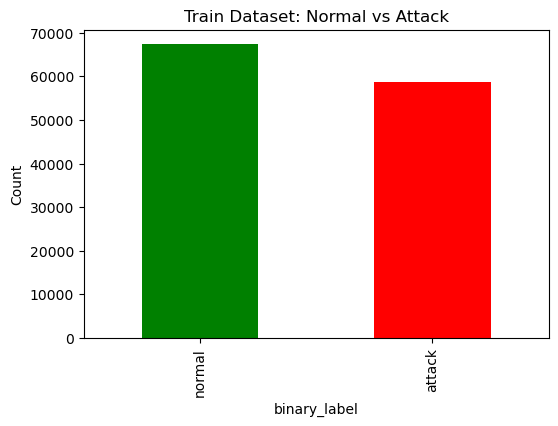

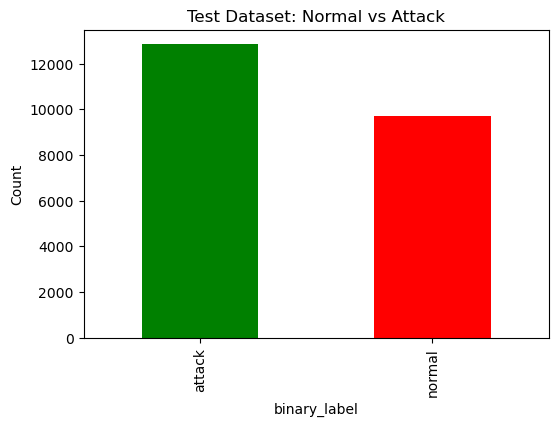

In [9]:
import matplotlib.pyplot as plt

# Plot Train
plt.figure(figsize=(6,4))
train_df['binary_label'].value_counts().plot(kind='bar', color=['green','red'])
plt.title("Train Dataset: Normal vs Attack")
plt.ylabel("Count")
plt.show()

# Plot Test
plt.figure(figsize=(6,4))
test_df['binary_label'].value_counts().plot(kind='bar', color=['green','red'])
plt.title("Test Dataset: Normal vs Attack")
plt.ylabel("Count")
plt.show()


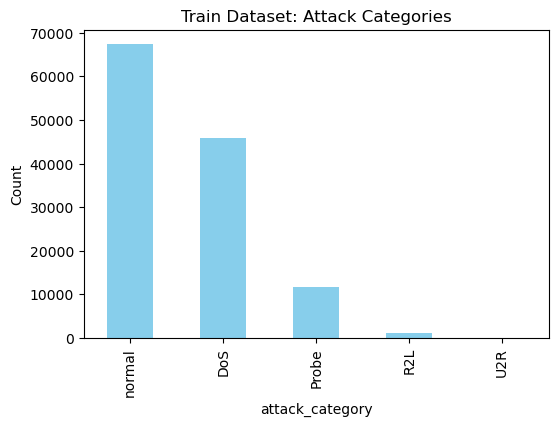

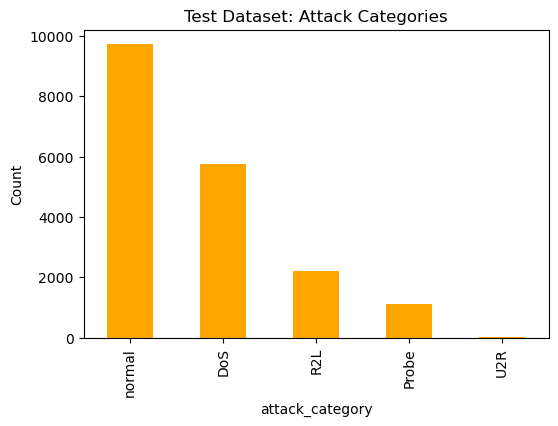

In [10]:
# Train categories
plt.figure(figsize=(6,4))
train_df['attack_category'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Train Dataset: Attack Categories")
plt.ylabel("Count")
plt.show()

# Test categories
plt.figure(figsize=(6,4))
test_df['attack_category'].value_counts().plot(kind='bar', color='orange')
plt.title("Test Dataset: Attack Categories")
plt.ylabel("Count")
plt.show()


In [11]:
## Check missing values in Train
print("Missing values in Train dataset:")
print(train_df.isnull().sum())

# Check missing values in Test
print("\nMissing values in Test dataset:")
print(test_df.isnull().sum())
 


Missing values in Train dataset:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_r

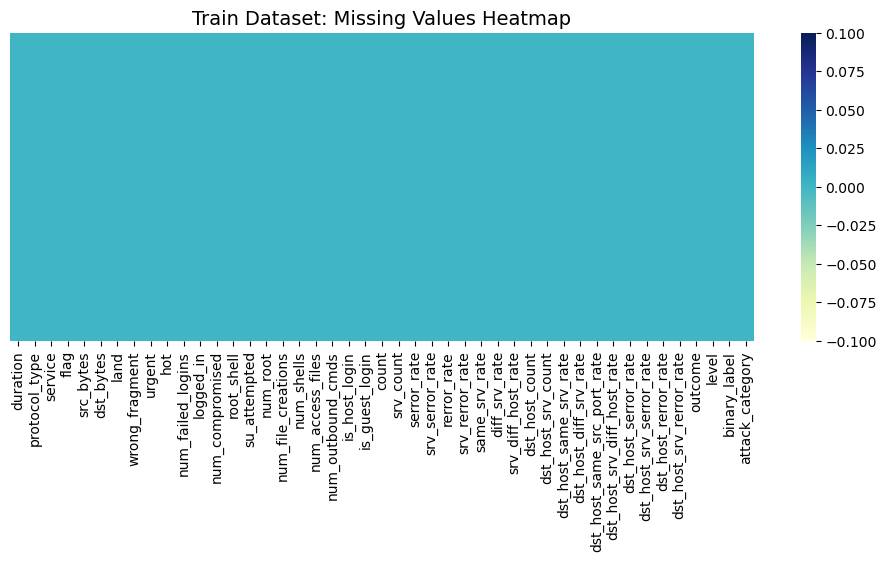

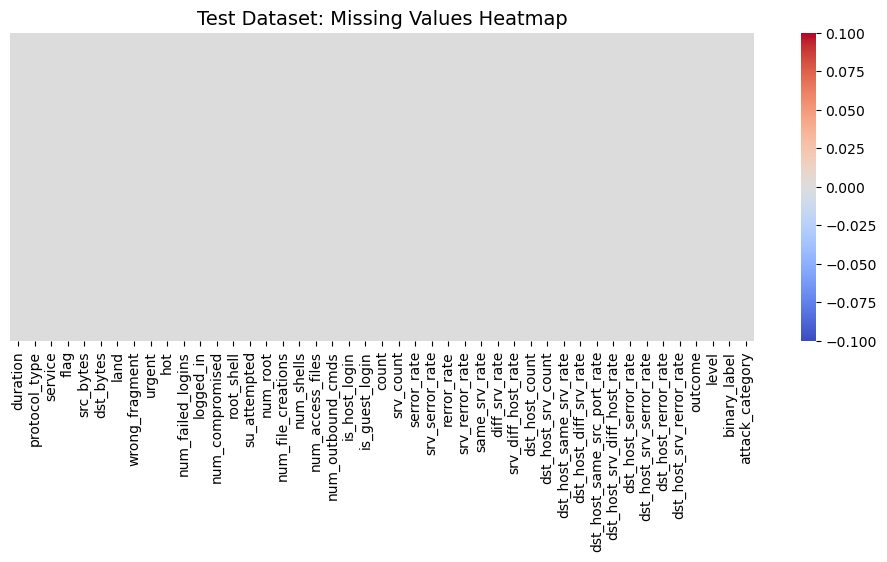

In [14]:
# For numeric features, fill missing with 0
numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns
train_df[numeric_cols] = train_df[numeric_cols].fillna(0)
test_df[numeric_cols]  = test_df[numeric_cols].fillna(0)

# For categorical features, fill missing with 'unknown'
categorical_cols = train_df.select_dtypes(include=['object']).columns
train_df[categorical_cols] = train_df[categorical_cols].fillna('unknown')
test_df[categorical_cols]  = test_df[categorical_cols].fillna('unknown')



import seaborn as sns
import matplotlib.pyplot as plt

# Train dataset missing values
plt.figure(figsize=(12,4))
sns.heatmap(train_df.isnull(), cmap="YlGnBu", cbar=True, yticklabels=False)
plt.title("Train Dataset: Missing Values Heatmap", fontsize=14)
plt.show()

# Test dataset missing values
plt.figure(figsize=(12,4))
sns.heatmap(test_df.isnull(), cmap="coolwarm", cbar=True, yticklabels=False)
plt.title("Test Dataset: Missing Values Heatmap", fontsize=14)
plt.show()





In [15]:
# Check & Remove Duplicates
# Check duplicates in Train
print("Duplicate rows in Train:", train_df.duplicated().sum())

# Check duplicates in Test
print("Duplicate rows in Test:", test_df.duplicated().sum())

# Remove duplicates if any
train_df = train_df.drop_duplicates()
test_df  = test_df.drop_duplicates()

print("After removing duplicates:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Duplicate rows in Train: 0
Duplicate rows in Test: 0
After removing duplicates:
Train shape: (125973, 45)
Test shape: (22544, 45)


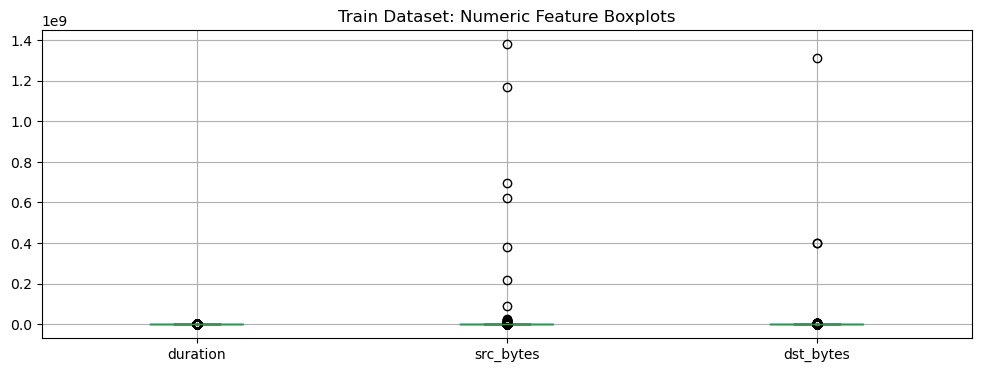

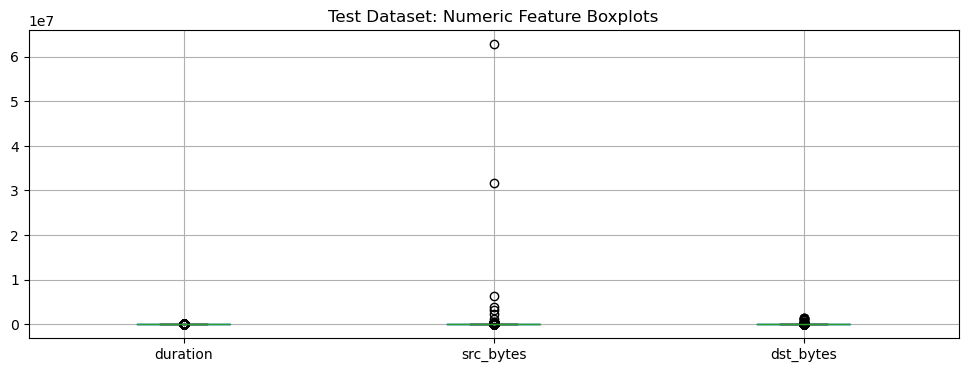

In [17]:
#check outliers
import matplotlib.pyplot as plt

numeric_cols = ['duration','src_bytes','dst_bytes']

# Train dataset boxplots
plt.figure(figsize=(12,4))
train_df[numeric_cols].boxplot()
plt.title("Train Dataset: Numeric Feature Boxplots")
plt.show()

# Test dataset boxplots
plt.figure(figsize=(12,4))
test_df[numeric_cols].boxplot()
plt.title("Test Dataset: Numeric Feature Boxplots")
plt.show()


In [19]:
# Numeric columns to cap
numeric_cols = ['duration','src_bytes','dst_bytes']

# Function to cap outliers using IQR
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Cap values
        df[col] = df[col].apply(lambda x: lower if x < lower else (upper if x > upper else x))
    return df

# Apply to train and test datasets
train_df = cap_outliers_iqr(train_df, numeric_cols)
test_df  = cap_outliers_iqr(test_df, numeric_cols)

# Quick check
train_df[numeric_cols].describe()


,duration,src_bytes,dst_bytes
count,88230.0,88230.000000,88230.000000
mean,0.0,48.498527,54.423597
std,0.0,72.850288,90.278380
min,0.0,0.000000,0.000000
25%,0.0,0.000000,0.000000
50%,0.0,0.000000,0.000000
75%,0.0,71.000000,91.000000
max,0.0,177.500000,227.500000


In [20]:
# Categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']

# One-Hot Encoding using pandas
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df  = pd.get_dummies(test_df, columns=categorical_cols)

# Align train and test columns to ensure same features
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# Check shapes after encoding
print("Train shape after One-Hot Encoding:", train_df.shape)
print("Test shape after One-Hot Encoding :", test_df.shape)


Train shape after One-Hot Encoding: (88230, 125)
Test shape after One-Hot Encoding : (14833, 125)


In [22]:
# Select all One-Hot encoded columns (those containing '_' in name)
onehot_cols = [col for col in train_df.columns if '_' in col]

# Show first 5 rows of One-Hot encoded columns
train_df[onehot_cols].head()


,src_bytes,dst_bytes,wrong_fragment,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,...,flag_OTH,flag_REJ,flag_RSTO,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,177.5,0.0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,146.0,0.0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0.0,0.0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
4,177.5,227.5,0,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
5,0.0,0.0,0,0,0,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False


In [28]:
# Map binary_label to numeric
train_df['binary_label_num'] = train_df['binary_label'].map({'normal':0, 'attack':1})
test_df['binary_label_num']  = test_df['binary_label'].map({'normal':0, 'attack':1})

# Check
print(train_df[['binary_label','binary_label_num']].head())


  binary_label  binary_label_num
0       normal                 0
1       normal                 0
2       attack                 1
4       normal                 0
5       attack                 1


In [29]:
#identify numeric colums
# All numeric columns except target/label columns
numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns.tolist()

# Remove target columns from scaling
numeric_cols = [col for col in numeric_cols if col not in ['level','binary_label','attack_category']]

print("Numeric columns to scale:", numeric_cols)


Numeric columns to scale: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'binary_label_num']


In [30]:
#Feature Scaling / Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train, transform both train and test
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols]  = scaler.transform(test_df[numeric_cols])

# Quick check
train_df[numeric_cols].head()


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label_num
0,0.0,1.770785,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,-0.646539,-0.589655,-0.288798,0.120078,-0.29451,-0.821180,-0.808030,-0.288186,-0.424989,-1.236976
1,0.0,1.338389,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,-0.868129,-0.964599,2.752223,2.449070,-0.29451,-0.821180,-0.808030,-0.435882,-0.424989,-1.236976
2,0.0,-0.665732,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,-0.637306,-0.744044,-0.182096,-0.437568,-0.29451,1.242444,1.245123,-0.435882,-0.424989,0.808423
4,0.0,1.770785,1.917152,-0.016835,-0.100857,0.0,-0.033517,-0.022137,1.894366,-0.010185,...,1.477031,1.240952,-0.448852,-0.437568,-0.29451,-0.821180,-0.808030,-0.435882,-0.424989,-1.236976
5,0.0,-0.665732,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,-0.701937,-0.810210,-0.075393,-0.437568,-0.29451,-0.821180,-0.808030,2.518042,2.407421,0.808423


Top 10 features correlated with attack:
 binary_label_num            1.000000
dst_host_serror_rate        0.648920
dst_host_srv_serror_rate    0.647903
serror_rate                 0.644919
srv_serror_rate             0.641344
count                       0.504220
dst_host_count              0.326200
dst_host_diff_srv_rate      0.267992
diff_srv_rate               0.198447
dst_host_srv_rerror_rate    0.174096
Name: binary_label_num, dtype: float64


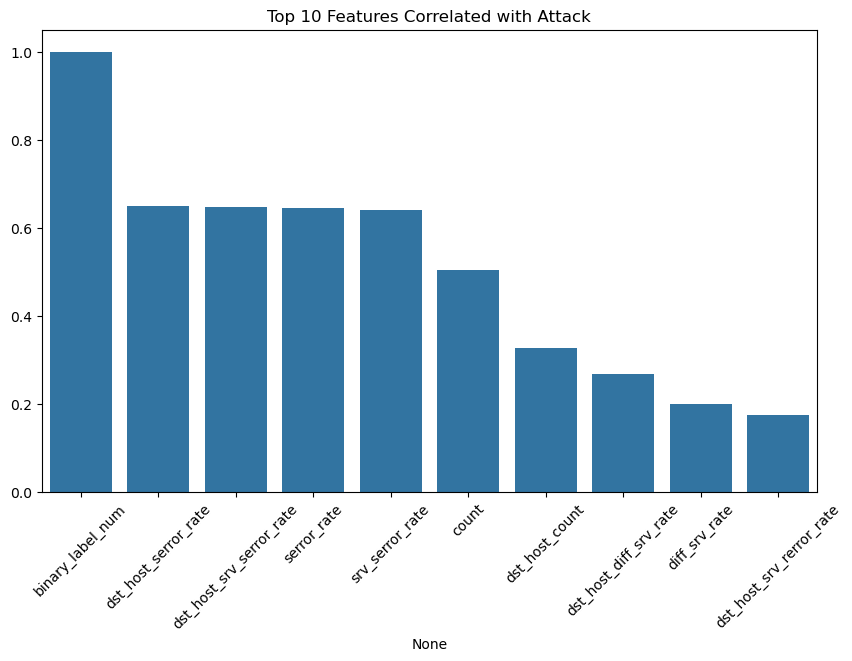

In [ ]:
#Feature Selection / Engineering
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns

# Compute correlation with target
corr = train_df[numeric_cols].corr()['binary_label_num'].sort_values(ascending=False)

# Show top 10 features most correlated with attack
print("Top 10 features correlated with attack:\n", corr.head(10))

# Plot barplot
plt.figure(figsize=(10,6))
sns.barplot(x=corr.head(10).index, y=corr.head(10).values)
plt.xticks(rotation=45)
plt.title("Top 10 Features Correlated with Attack")
plt.show()


In [39]:
# Separate features and target

# Training data
X_train = train_df.drop(['binary_label','attack_category','level','binary_label_num'], axis=1)
y_train = train_df['binary_label_num']

# Test data
X_test = test_df.drop(['binary_label','attack_category','level','binary_label_num'], axis=1)
y_test = test_df['binary_label_num']



# Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

# Final check for missing values
print("Missing values in train:", X_train.isnull().sum().sum())
print("Missing values in test :", X_test.isnull().sum().sum())

# Check first few rows of features
X_train.head()


X_train shape: (88230, 122)
y_train shape: (88230,)
X_test shape : (14833, 122)
y_test shape : (14833,)
Missing values in train: 0
Missing values in test : 0


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_OTH,flag_REJ,flag_RSTO,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,1.770785,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,False,False,False,False,False,False,False,False,True,False
1,0.0,1.338389,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,False,False,False,False,False,False,False,False,True,False
2,0.0,-0.665732,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,False,False,False,False,True,False,False,False,False,False
4,0.0,1.770785,1.917152,-0.016835,-0.100857,0.0,-0.033517,-0.022137,1.894366,-0.010185,...,False,False,False,False,False,False,False,False,True,False
5,0.0,-0.665732,-0.602845,-0.016835,-0.100857,0.0,-0.033517,-0.022137,-0.527881,-0.010185,...,False,True,False,False,False,False,False,False,False,False


In [44]:
X_train = train_df.drop(['binary_label', 'attack_category', 'level', 'binary_label_num','outcome'], axis=1)
X_test  = test_df.drop(['binary_label', 'attack_category', 'level', 'binary_label_num','outcome'], axis=1)


In [45]:
# List all columns that are not numeric
print(X_train.select_dtypes(exclude=['int64','float64']).columns)


Index(['protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp',
       'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol',
       'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns',
       'service_ctf', 'service_daytime', 'service_discard', 'service_domain',
       'service_domain_u', 'service_echo', 'service_eco_i', 'service_ecr_i',
       'service_efs', 'service_exec', 'service_finger', 'service_ftp',
       'service_ftp_data', 'service_gopher', 'service_harvest',
       'service_hostnames', 'service_http', 'service_http_2784',
       'service_http_443', 'service_http_8001', 'service_imap4',
       'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap',
       'service_link', 'service_login', 'service_mtp', 'service_name',
       'service_netbios_dgm', 'service_netbios_ns', 'service_netbios_ssn',
       'service_netstat', 'service_nnsp', 'service_nntp', 'service_ntp_u',
       'service_other', 'service_pm_dump', 'service_pop_2', 's

In [46]:
X_train = X_train.astype(float)
X_test  = X_test.astype(float)


In [47]:
# -------------------------------
# Step: Handle Data Imbalance using SMOTE
# -------------------------------

# Install imbalanced-learn if not already installed
# !pip install imbalanced-learn

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE on preprocessed training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check class distribution before and after SMOTE
print("Original class distribution:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_res.value_counts())


Original class distribution:
 binary_label_num
1    53358
0    34872
Name: count, dtype: int64

After SMOTE:
 binary_label_num
0    53358
1    53358
Name: count, dtype: int64
